In [3]:
pip install ultralytics opencv-python matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 29.3 MB/s eta 0:00:00


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

0: 640x480 4 persons, 1 bus, 74.6ms
Speed: 9.9ms preprocess, 74.6ms inference, 8.0ms postprocess per image at shape (1, 3, 640, 480)


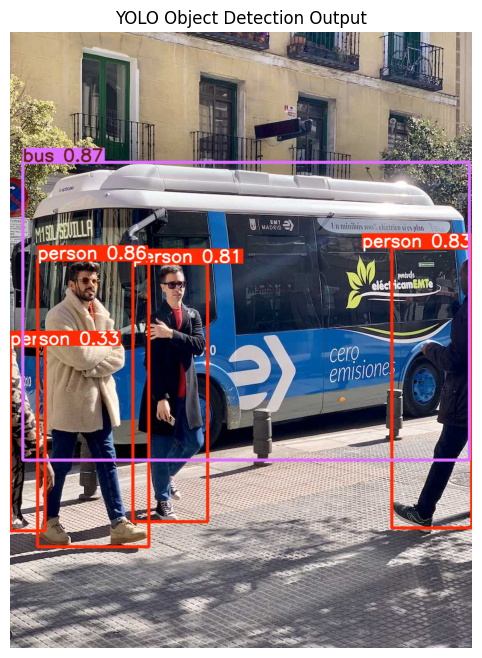


--- Detected Objects ---
Detected: bus | Confidence: 0.87
Detected: person | Confidence: 0.86
Detected: person | Confidence: 0.83
Detected: person | Confidence: 0.81
Detected: person | Confidence: 0.33


In [4]:
from ultralytics import YOLO
import cv2
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

model = YOLO('yolov8n.pt')

url = "https://ultralytics.com/images/bus.jpg"

resp = urllib.request.urlopen(url)
image = np.asarray(bytearray(resp.read()), dtype="uint8")
image = cv2.imdecode(image, cv2.IMREAD_COLOR)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

results = model(image_rgb)

annotated_image = results[0].plot()
plt.figure(figsize=(8, 8))
plt.imshow(annotated_image)
plt.axis('off')
plt.title("YOLO Object Detection Output")
plt.show()

print("\n--- Detected Objects ---")
for obj in results[0].boxes.data:
    x1, y1, x2, y2, conf, cls = obj
    print(f"Detected: {model.names[int(cls)]} | Confidence: {float(conf):.2f}")
